# Lexical Priming and Attentional Economics on SERPs

> **Task constraint note:** AdSERP participants completed forced-click transactional queries in a controlled lab environment — no competing tabs, no abandonment, no query reformulation. The priming effect (overlap → shorter fixation) depends on SERP content structure, not task constraints, and should generalize. But fixation durations may be longer than natural browsing (forced thoroughness), compressing the variance that overlap explains. See [findings caveats](docs/findings.md#caveats).

**The received finding:** Users evaluate SERP results faster as they scroll down. This is typically attributed to decreasing effort, attention fatigue, or declining result relevance (position bias).

**The alternative hypothesis:** Acceleration is driven by **cumulative lexical priming**. After reading results 1-3 for "buy momentum flashlight," the user has built a strong context model. Result 7 shares vocabulary with prior results — its title, snippet, and domain are partially redundant. The user can accept/reject faster not because they care less, but because they've accumulated enough context to make a quicker decision.

**Lexical homogeneity as the mediating variable:** For each result at position N, compute how much of its vocabulary has already appeared in results 1 through N-1. High cumulative overlap = strong priming = faster evaluation. Low overlap (novel result) = slower evaluation, and potentially a trigger for scroll regressions (the user scrolls back to re-evaluate in light of new information).

**What this notebook computes:**
1. Per-result lexical features: title/snippet text, token sets, cumulative overlap with prior results
2. Per-SERP homogeneity curve: how overlap accumulates as you go down the page
3. Correlation with behavioral data: does higher priming predict faster fixation time on that result?
4. Regression prediction: does a novel result (low overlap) predict an upcoming scroll regression?

**Dataset:** AdSERP SERP HTML files (self-contained, with CSS/images) + fixation data + scroll data.

In [1]:
import os
import csv
import json
import re
import math
import xml.etree.ElementTree as ET
from collections import defaultdict, Counter
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 150,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

DATA_DIR = 'AdSERP/data'
SERP_DIR = os.path.join(DATA_DIR, 'serps')
FIXATION_DIR = os.path.join(DATA_DIR, 'fixation-data')
MOUSE_DIR = os.path.join(DATA_DIR, 'mouse-movement-data')
METADATA_DIR = os.path.join(DATA_DIR, 'trial-metadata')
AD_DIR = os.path.join(DATA_DIR, 'ad-boundary-data')

# Check if SERP HTML is available
serp_files = list(Path(SERP_DIR).glob('*.html')) if os.path.exists(SERP_DIR) else []
print(f"SERP HTML files: {len(serp_files)}")
print(f"Fixation files: {len(list(Path(FIXATION_DIR).glob('*.csv')))}")

if not serp_files:
    print("\n⚠ SERP HTML not yet downloaded. Run:")
    print("  cd AdSERP/data && unzip serps.zip")

SERP HTML files: 2776
Fixation files: 2776


## Step 1: Extract structured result text from SERP HTML

Google SERPs have a consistent DOM structure. Each organic result has:
- Title (`h3` inside the result container)
- Snippet (text under the title)
- URL (displayed green URL)

We extract these per result, ordered by vertical position on the page.

In [2]:
# Stopwords for English — lightweight, no NLTK dependency
STOPWORDS = set('a an the and or but in on at to for of is it its this that these those '
                'be am are was were been being have has had do does did will would shall '
                'should can could may might must from by with as not no nor so if then '
                'than too very just about above after again all also any because before '
                'between both during each few how more most other some such through until '
                'where which while who whom why into over under'.split())

def tokenize(text):
    """Simple whitespace + punctuation tokenizer, lowercased, stopwords removed."""
    tokens = re.findall(r'[a-z0-9]+', text.lower())
    return [t for t in tokens if t not in STOPWORDS and len(t) > 1]

def extract_serp_results(html_path):
    """Extract ordered list of search results from a Google SERP HTML file.
    
    Returns list of dicts: {position, title, snippet, url, tokens, y_offset}
    """
    with open(html_path, 'r', encoding='utf-8', errors='ignore') as f:
        soup = BeautifulSoup(f.read(), 'html.parser')
    
    results = []
    
    # Google organic results are typically in divs with class 'g' inside #rso
    rso = soup.find(id='rso')
    if not rso:
        # Try broader search
        rso = soup
    
    # Find all result containers — look for h3 tags (titles)
    for i, h3 in enumerate(rso.find_all('h3')):
        title_text = h3.get_text(strip=True)
        
        # Walk up to find the result container
        container = h3.parent
        for _ in range(5):
            if container and container.parent:
                container = container.parent
                # Check if this looks like a result container
                if container.get('class') and any('g' in c for c in container.get('class', [])):
                    break
        
        # Extract snippet — text content near the h3, excluding the title itself
        snippet_parts = []
        if container:
            for text_elem in container.find_all(['span', 'div'], recursive=True):
                text = text_elem.get_text(strip=True)
                if text and text != title_text and len(text) > 20:
                    snippet_parts.append(text)
        
        # Get URL
        link = h3.find_parent('a')
        url = link.get('href', '') if link else ''
        
        # Combine all text for this result
        all_text = title_text + ' ' + ' '.join(snippet_parts[:3])  # limit snippet noise
        tokens = tokenize(all_text)
        
        results.append({
            'position': i,
            'title': title_text,
            'snippet': ' '.join(snippet_parts[:2])[:200],
            'url': url,
            'tokens': tokens,
            'token_set': set(tokens),
        })
    
    return results

# Test on one file
if serp_files:
    test_results = extract_serp_results(serp_files[0])
    print(f"Test SERP: {serp_files[0].name}")
    print(f"Results extracted: {len(test_results)}")
    for r in test_results[:5]:
        print(f"  [{r['position']}] {r['title'][:60]}... ({len(r['tokens'])} tokens)")
else:
    print("Waiting for SERP HTML download...")

Test SERP: p023-b1-t10.html
Results extracted: 10
  [0] Tone Tattoo | Analog Delay / Chorus / Distortion Multi-Effec... (80 tokens)
  [1] Comprar Electro Harmonix Tone Tattoo - Txirula... (83 tokens)
  [2] Electro-Harmonix Tone Tattoo Multi-Effects Pedal... (141 tokens)
  [3] Electro-Harmonix Tone Tattoo Analog Multi-Effect Pedal... (104 tokens)
  [4] Electro Harmonix Tone Tattoo - Banzai Music GmbH... (119 tokens)


## Step 2: Cumulative Lexical Overlap

For each result at position N, compute:
- **Cumulative overlap ratio:** `|tokens_N ∩ tokens_1..N-1| / |tokens_N|` — fraction of this result's vocabulary already seen
- **Novel token count:** `|tokens_N - tokens_1..N-1|` — new information introduced by this result
- **Jaccard similarity:** against the cumulative token pool

Also compute SERP-level metrics:
- **SERP homogeneity:** mean pairwise Jaccard across all results (high = all results say the same thing)
- **Query specificity:** token count in the search query (from metadata slug)

In [3]:
def compute_priming_metrics(results):
    """Compute cumulative lexical overlap for an ordered list of SERP results.
    
    Returns the results list augmented with priming metrics.
    """
    cumulative_tokens = set()
    query_tokens = set()  # tokens from result 0 title as proxy for query terms
    
    for i, r in enumerate(results):
        tokens = r['token_set']
        
        if i == 0:
            # First result: no prior context. Use its title as query proxy.
            query_tokens = set(tokenize(r['title']))
            r['cumulative_overlap'] = 0.0
            r['novel_tokens'] = len(tokens)
            r['jaccard_vs_prior'] = 0.0
            r['cumulative_pool_size'] = len(tokens)
        else:
            overlap = tokens & cumulative_tokens
            novel = tokens - cumulative_tokens
            union = tokens | cumulative_tokens
            
            r['cumulative_overlap'] = len(overlap) / len(tokens) if tokens else 0.0
            r['novel_tokens'] = len(novel)
            r['jaccard_vs_prior'] = len(overlap) / len(union) if union else 0.0
            r['cumulative_pool_size'] = len(cumulative_tokens)
        
        # Query term overlap — how many of this result's tokens match the query?
        r['query_overlap'] = len(tokens & query_tokens) / len(tokens) if tokens else 0.0
        
        cumulative_tokens |= tokens
    
    # SERP-level homogeneity: mean pairwise Jaccard
    pairwise_jaccards = []
    for i in range(len(results)):
        for j in range(i+1, len(results)):
            ti = results[i]['token_set']
            tj = results[j]['token_set']
            union = ti | tj
            if union:
                pairwise_jaccards.append(len(ti & tj) / len(union))
    
    serp_homogeneity = np.mean(pairwise_jaccards) if pairwise_jaccards else 0.0
    
    return results, serp_homogeneity

def get_query_slug(trial_id):
    """Extract search query from trial metadata."""
    path = os.path.join(METADATA_DIR, f'{trial_id}.xml')
    try:
        tree = ET.parse(path)
        task = tree.find('.//task').text
        slug = task.split(' | ')[1].strip() if ' | ' in task else task
        return slug.replace('-', ' ')
    except:
        return ''

# Process all SERPs
print("Computing lexical priming metrics...")
serp_data = {}  # trial_id -> {results, homogeneity}
processed = 0

for html_path in sorted(serp_files):
    tid = html_path.stem
    try:
        results = extract_serp_results(html_path)
        if len(results) >= 3:
            results, homogeneity = compute_priming_metrics(results)
            query = get_query_slug(tid)
            serp_data[tid] = {
                'results': results,
                'homogeneity': homogeneity,
                'n_results': len(results),
                'query': query,
            }
            processed += 1
    except:
        pass
    if processed % 500 == 0 and processed > 0:
        print(f"  {processed}...")

print(f"\nProcessed {processed} SERPs")

# Aggregate priming curve
max_pos = 15
overlap_by_position = defaultdict(list)
novel_by_position = defaultdict(list)

for tid, data in serp_data.items():
    for r in data['results']:
        if r['position'] < max_pos:
            overlap_by_position[r['position']].append(r['cumulative_overlap'])
            novel_by_position[r['position']].append(r['novel_tokens'])

positions = sorted(overlap_by_position.keys())
mean_overlap = [np.mean(overlap_by_position[p]) for p in positions]
mean_novel = [np.mean(novel_by_position[p]) for p in positions]
n_at_pos = [len(overlap_by_position[p]) for p in positions]

print(f"\nCumulative overlap by SERP position:")
print(f"{'Pos':>4} {'Overlap':>8} {'Novel':>6} {'N':>6}")
for p, o, n, count in zip(positions, mean_overlap, mean_novel, n_at_pos):
    print(f"{p:>4} {o:>8.1%} {n:>6.1f} {count:>6}")

Computing lexical priming metrics...


  500...


  1000...


  1500...


  2000...


  2500...



Processed 2772 SERPs

Cumulative overlap by SERP position:
 Pos  Overlap  Novel      N
   0     0.0%   28.0   2772
   1    38.4%   19.4   2772
   2    38.0%   24.2   2772
   3    46.2%   20.9   2769
   4    49.7%   20.6   2767
   5    55.5%   14.9   2761
   6    57.6%   13.2   2757
   7    59.5%   11.3   2754
   8    60.2%   10.9   2747
   9    61.9%    9.7   2643
  10    72.6%    7.0   1598
  11    96.9%    0.7    240
  12    96.0%    1.0      3


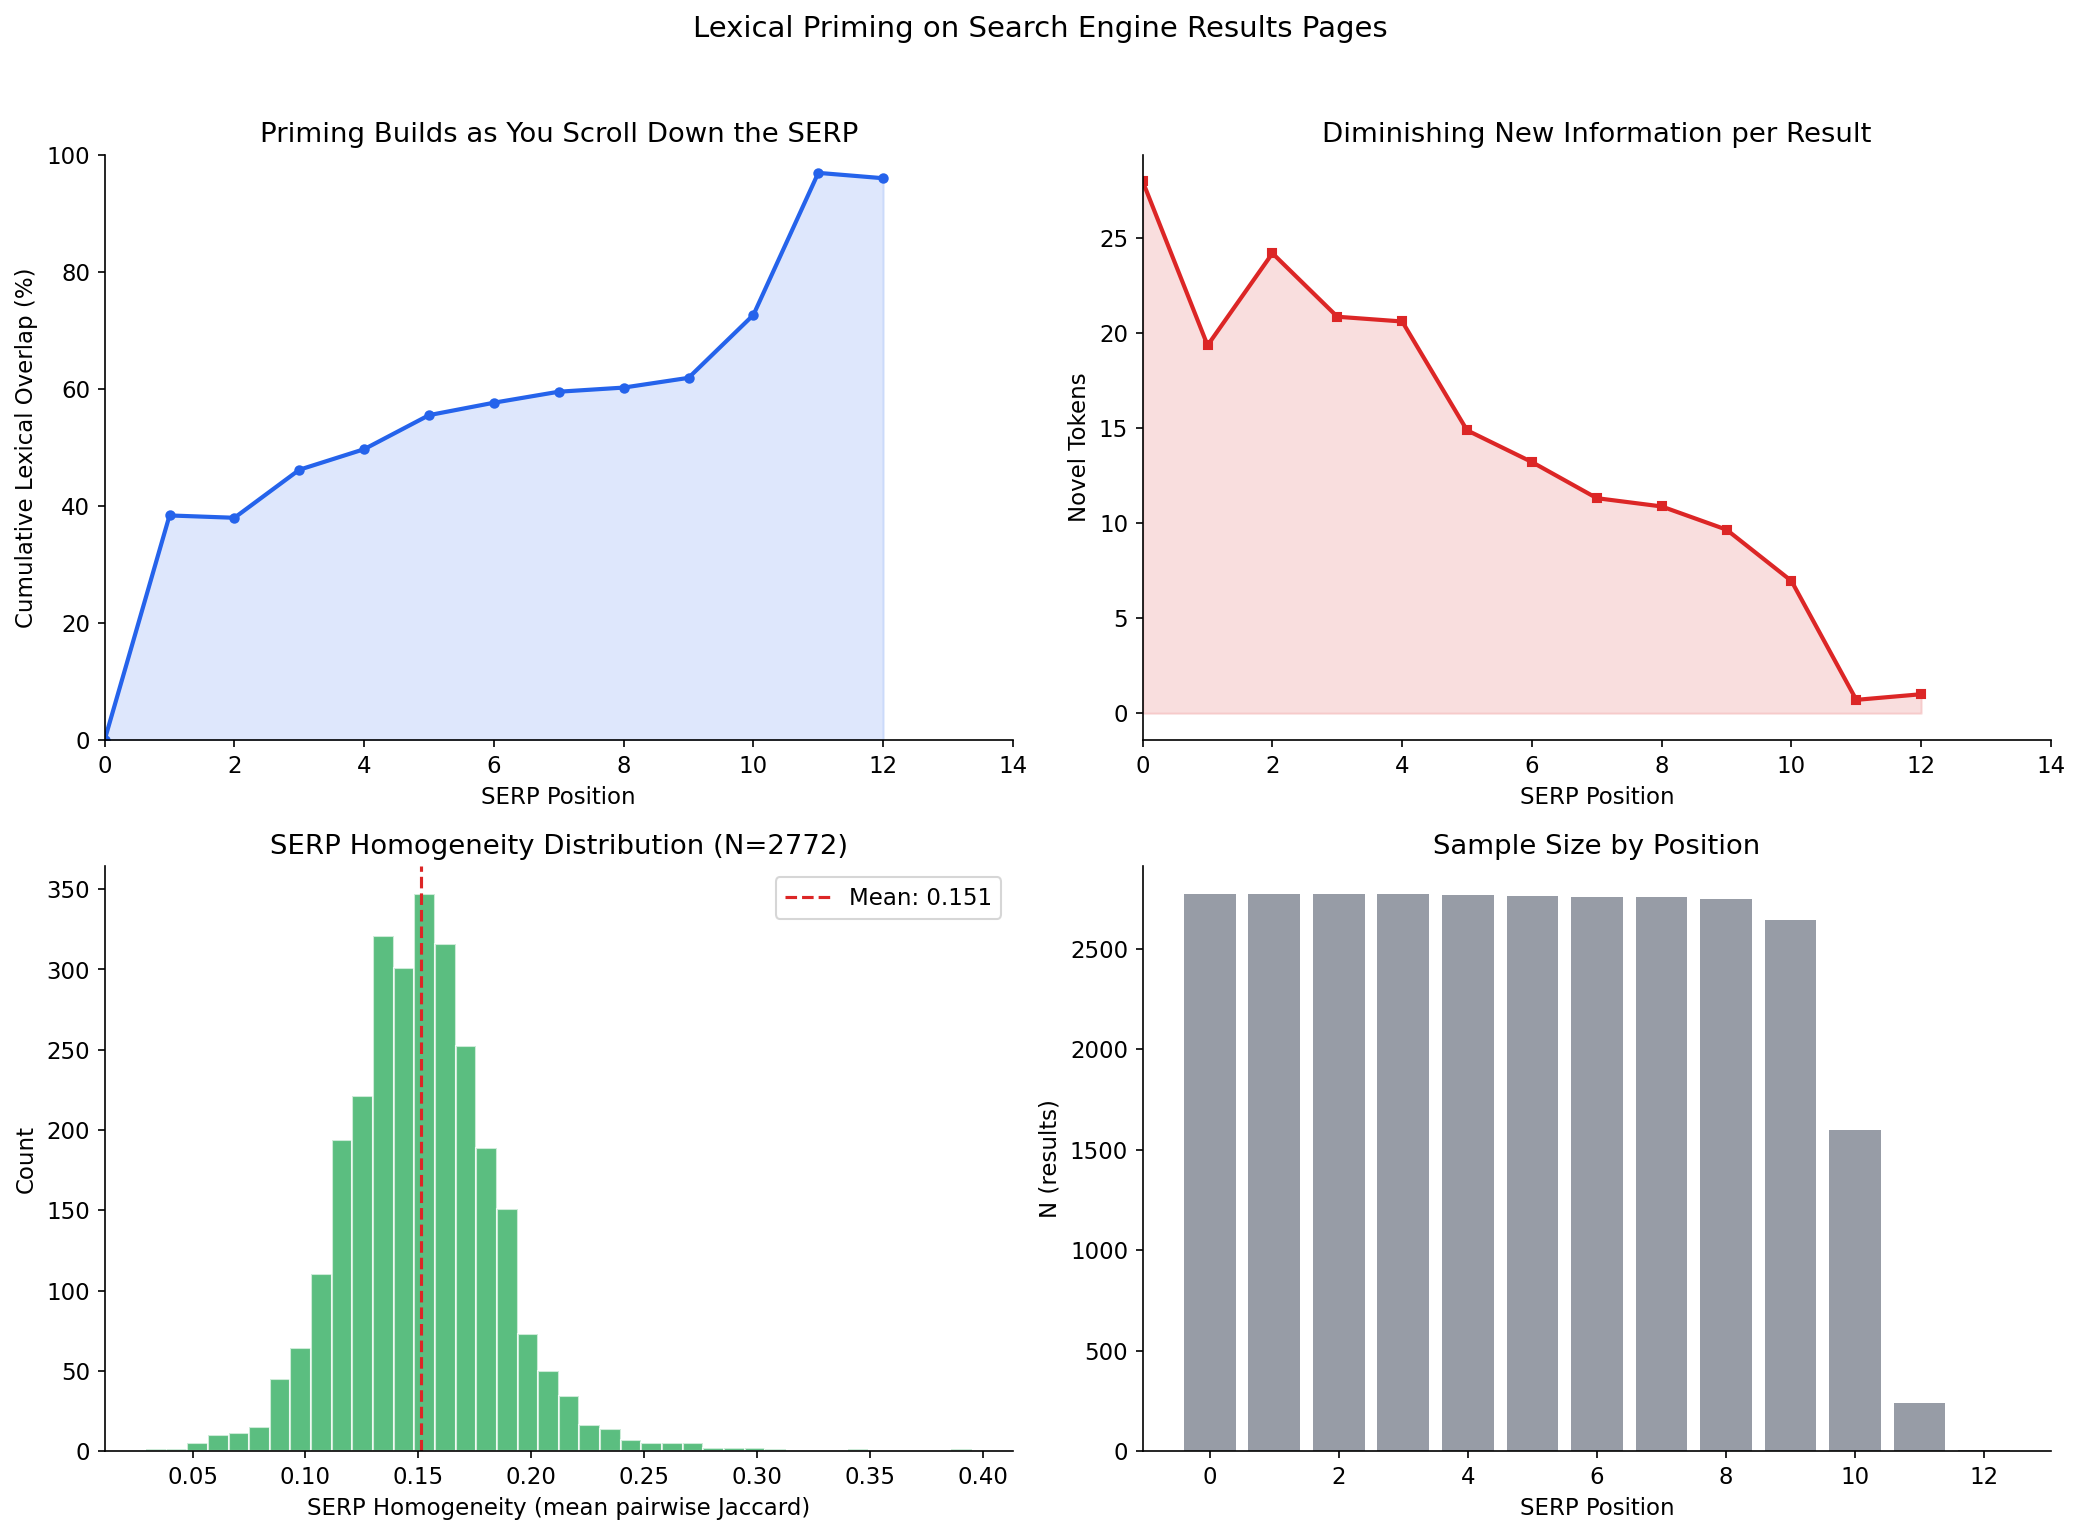

Mean SERP homogeneity: 0.151
Position 1 overlap: 38.4%
Position 5 overlap: 55.5%
Position 9 overlap: 61.9%


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1: Cumulative overlap curve
ax = axes[0, 0]
ax.plot(positions, [o * 100 for o in mean_overlap], color='#2563eb', linewidth=2, marker='o', markersize=4)
ax.fill_between(positions, 0, [o * 100 for o in mean_overlap], alpha=0.15, color='#2563eb')
ax.set_xlabel('SERP Position')
ax.set_ylabel('Cumulative Lexical Overlap (%)')
ax.set_title('Priming Builds as You Scroll Down the SERP')
ax.set_xlim(0, max_pos - 1)
ax.set_ylim(0, 100)

# 2: Novel tokens per position (decreasing information)
ax = axes[0, 1]
ax.plot(positions, mean_novel, color='#dc2626', linewidth=2, marker='s', markersize=4)
ax.fill_between(positions, 0, mean_novel, alpha=0.15, color='#dc2626')
ax.set_xlabel('SERP Position')
ax.set_ylabel('Novel Tokens')
ax.set_title('Diminishing New Information per Result')
ax.set_xlim(0, max_pos - 1)

# 3: SERP homogeneity distribution
ax = axes[1, 0]
homogeneities = [d['homogeneity'] for d in serp_data.values()]
ax.hist(homogeneities, bins=40, color='#16a34a', alpha=0.7, edgecolor='white')
ax.set_xlabel('SERP Homogeneity (mean pairwise Jaccard)')
ax.set_ylabel('Count')
ax.set_title(f'SERP Homogeneity Distribution (N={len(homogeneities)})')
ax.axvline(np.mean(homogeneities), color='#dc2626', linestyle='--', 
           label=f'Mean: {np.mean(homogeneities):.3f}')
ax.legend()

# 4: Sample size per position
ax = axes[1, 1]
ax.bar(positions, n_at_pos, color='#6b7280', alpha=0.7)
ax.set_xlabel('SERP Position')
ax.set_ylabel('N (results)')
ax.set_title('Sample Size by Position')

plt.suptitle('Lexical Priming on Search Engine Results Pages', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plot_priming1_overview.png', dpi=200, bbox_inches='tight')
plt.show()

# Key stats
print(f"Mean SERP homogeneity: {np.mean(homogeneities):.3f}")
print(f"Position 1 overlap: {mean_overlap[1]*100:.1f}%")
if len(mean_overlap) > 5:
    print(f"Position 5 overlap: {mean_overlap[5]*100:.1f}%")
if len(mean_overlap) > 9:
    print(f"Position 9 overlap: {mean_overlap[9]*100:.1f}%")

## Step 3: Link priming to behavioral data

Now the critical connection: does lexical overlap predict scroll regressions? A result with low cumulative overlap (high novelty) introduces information that doesn't fit the user's accumulated context model. This is the attentional micro-economics argument — novel results demand re-evaluation of prior results.

We need the ad boundary data to map fixation Y positions to SERP result positions, then link each fixation to its nearest result's priming metrics.

In [5]:
# Load scroll regression data per trial (reuse logic from scroll_regressions notebook)
def count_regressions(trial_id):
    """Count scroll regressions for a trial."""
    path = os.path.join(MOUSE_DIR, f'{trial_id}.csv')
    scrolls = []
    click_t = None
    with open(path) as f:
        for r in csv.DictReader(f):
            t = int(float(r['timestamp']))
            if r['event'] == 'scroll':
                scrolls.append((t, float(r['ypos'])))
            if r['event'] == 'click':
                click_t = t
    
    if len(scrolls) < 2 or not click_t:
        return {'n_regressions': 0, 'has_scroll': False, 'trial_duration_s': 0}
    
    # Segment gestures
    regressions = 0
    gesture_start_y = scrolls[0][1]
    for i in range(1, len(scrolls)):
        if scrolls[i][0] - scrolls[i-1][0] > 200:
            delta = scrolls[i-1][1] - gesture_start_y
            if delta < -10:
                regressions += 1
            gesture_start_y = scrolls[i][1]
    # Last gesture
    delta = scrolls[-1][1] - gesture_start_y
    if delta < -10:
        regressions += 1
    
    return {
        'n_regressions': regressions,
        'has_scroll': True,
        'trial_duration_s': (click_t - scrolls[0][0]) / 1000.0,
        'max_scroll': max(s[1] for s in scrolls),
    }

# For each trial with SERP data, compute homogeneity + regression count
print("Linking SERP priming to scroll regressions...")
linked = []
for tid, data in serp_data.items():
    try:
        reg_info = count_regressions(tid)
        if reg_info['has_scroll']:
            linked.append({
                'trial': tid,
                'homogeneity': data['homogeneity'],
                'n_results': data['n_results'],
                'n_regressions': reg_info['n_regressions'],
                'trial_duration_s': reg_info['trial_duration_s'],
                'max_scroll': reg_info.get('max_scroll', 0),
                'query': data['query'],
            })
    except:
        pass

print(f"Linked {len(linked)} trials with both SERP content and scroll data")

# Split by homogeneity terciles
homos = [l['homogeneity'] for l in linked]
t1, t2 = np.percentile(homos, [33, 66])

low_homo = [l for l in linked if l['homogeneity'] <= t1]
mid_homo = [l for l in linked if t1 < l['homogeneity'] <= t2]
high_homo = [l for l in linked if l['homogeneity'] > t2]

print(f"\nHomogeneity terciles:")
print(f"  Low  (≤{t1:.3f}): N={len(low_homo)}, mean regressions={np.mean([l['n_regressions'] for l in low_homo]):.2f}")
print(f"  Mid  ({t1:.3f}-{t2:.3f}): N={len(mid_homo)}, mean regressions={np.mean([l['n_regressions'] for l in mid_homo]):.2f}")
print(f"  High (>{t2:.3f}): N={len(high_homo)}, mean regressions={np.mean([l['n_regressions'] for l in high_homo]):.2f}")

# Correlation
reg_counts = [l['n_regressions'] for l in linked]
homo_vals = [l['homogeneity'] for l in linked]
r_corr = np.corrcoef(homo_vals, reg_counts)[0, 1]
print(f"\nCorrelation (homogeneity × regressions): r = {r_corr:.3f}")

durations = [l['trial_duration_s'] for l in linked]
r_dur = np.corrcoef(homo_vals, durations)[0, 1]
print(f"Correlation (homogeneity × trial duration): r = {r_dur:.3f}")

Linking SERP priming to scroll regressions...


Linked 2262 trials with both SERP content and scroll data

Homogeneity terciles:
  Low  (≤0.136): N=747, mean regressions=1.95
  Mid  (0.136-0.162): N=746, mean regressions=1.86
  High (>0.162): N=769, mean regressions=1.91

Correlation (homogeneity × regressions): r = -0.015
Correlation (homogeneity × trial duration): r = -0.041


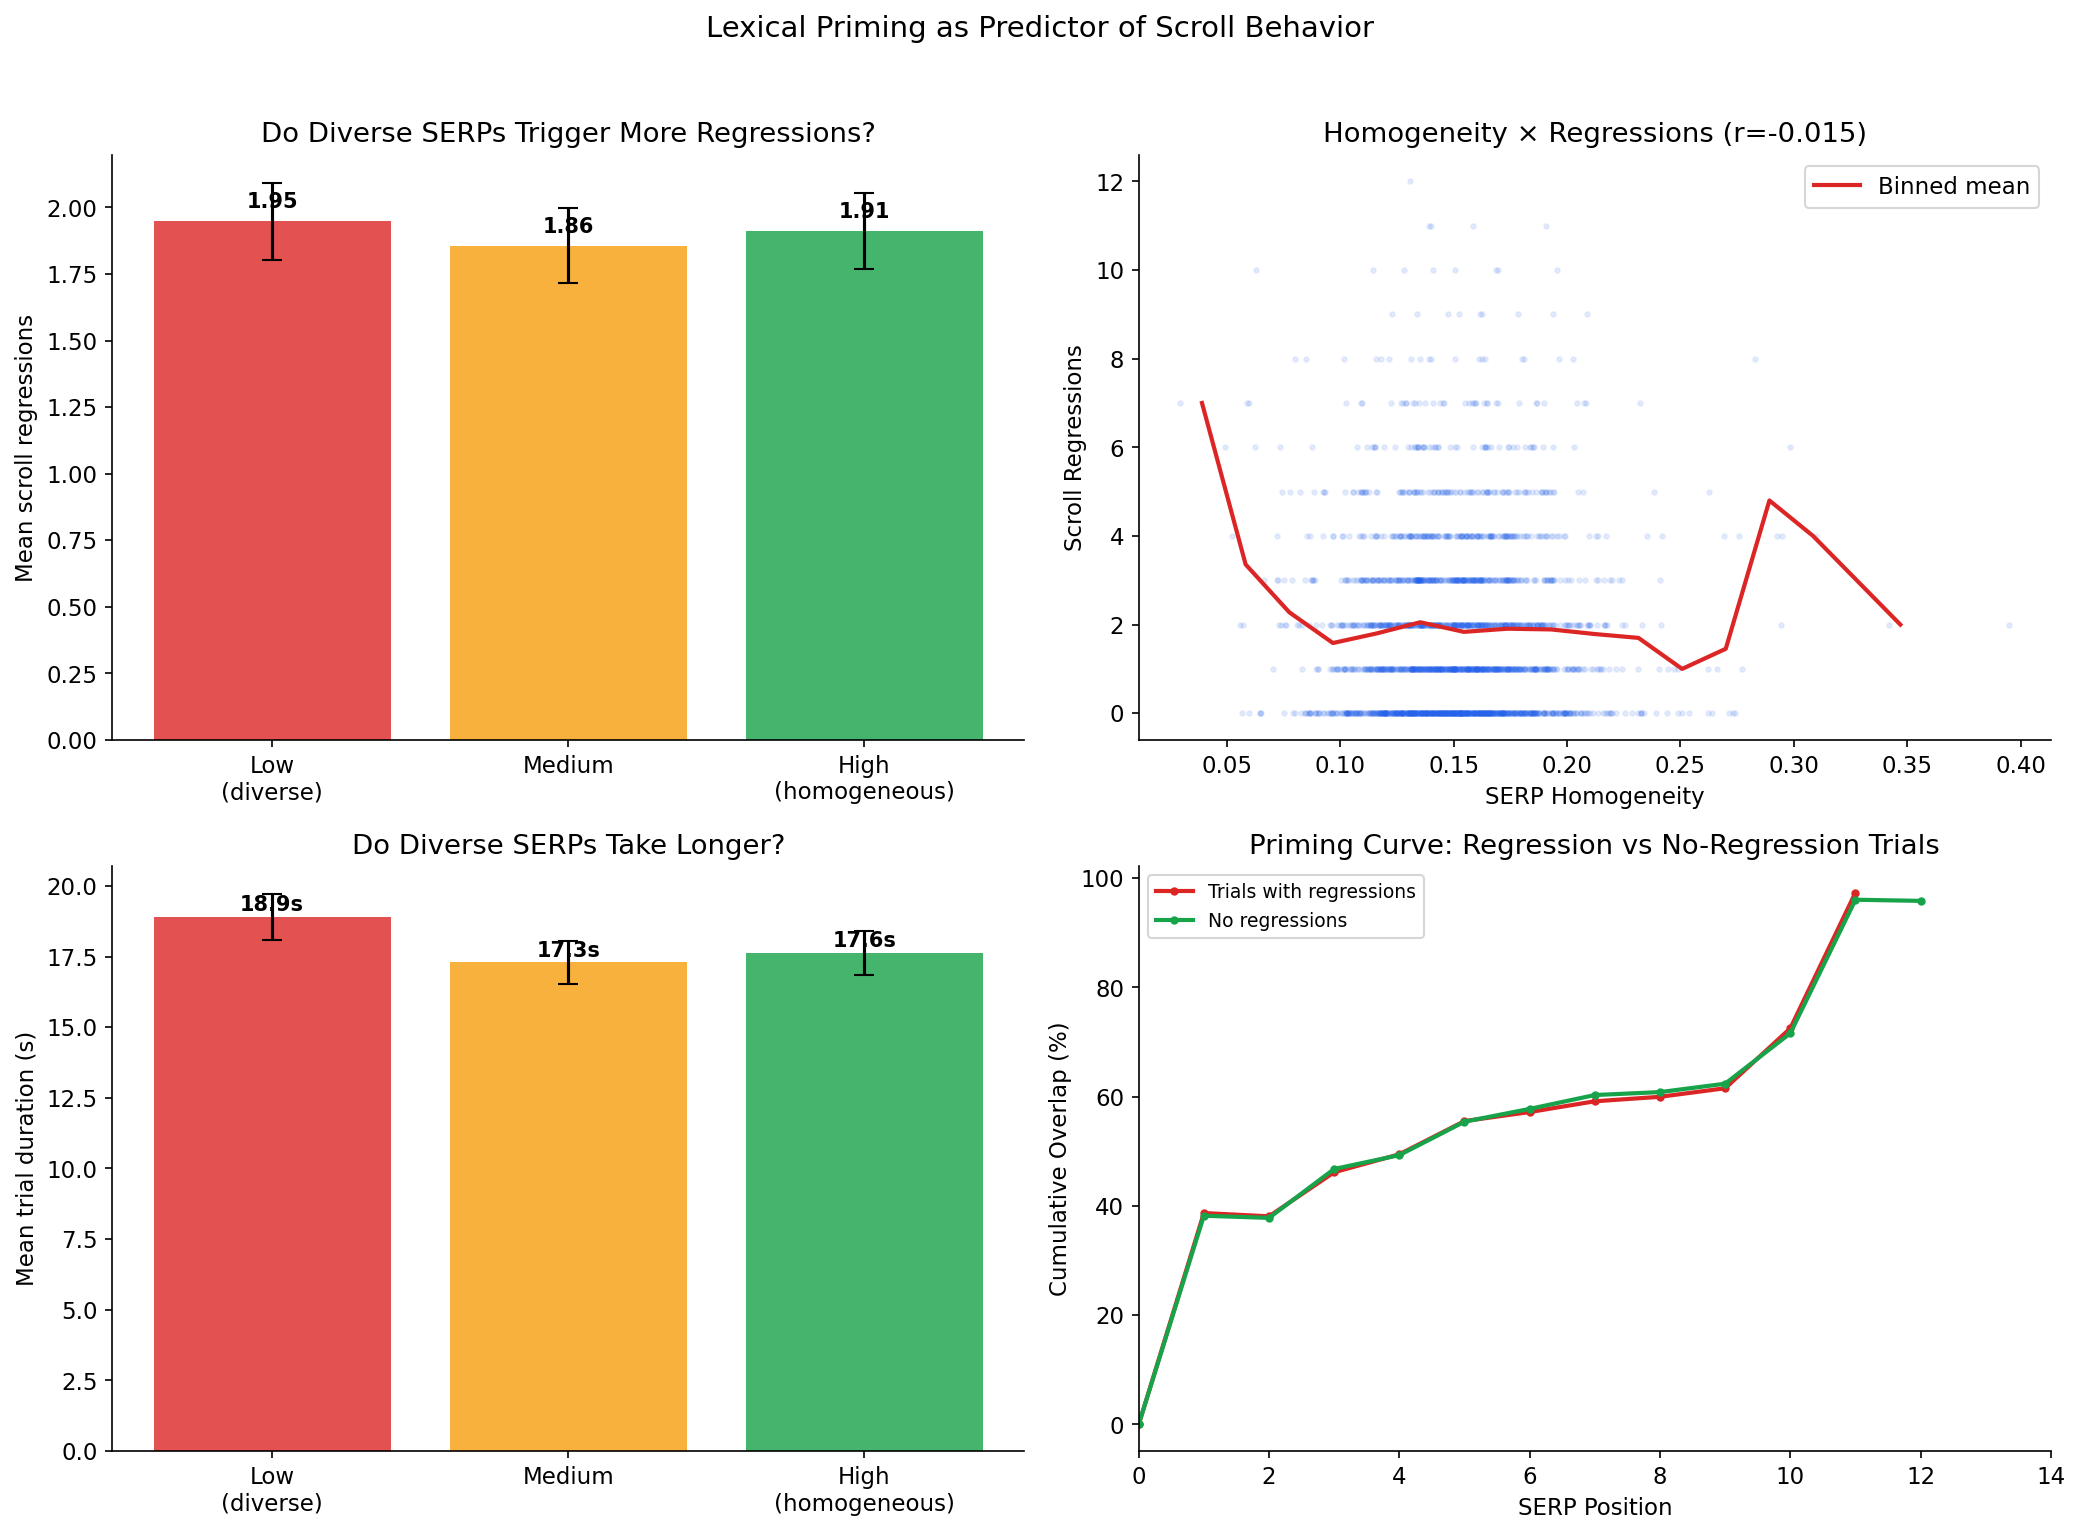

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1: Regression count by homogeneity tercile
ax = axes[0, 0]
tercile_labels = ['Low\n(diverse)', 'Medium', 'High\n(homogeneous)']
tercile_means = [np.mean([l['n_regressions'] for l in g]) for g in [low_homo, mid_homo, high_homo]]
tercile_sems = [np.std([l['n_regressions'] for l in g]) / np.sqrt(len(g)) for g in [low_homo, mid_homo, high_homo]]
bars = ax.bar(tercile_labels, tercile_means, yerr=[s*1.96 for s in tercile_sems], 
              color=['#dc2626', '#f59e0b', '#16a34a'], capsize=5, alpha=0.8)
ax.set_ylabel('Mean scroll regressions')
ax.set_title('Do Diverse SERPs Trigger More Regressions?')
for bar, m in zip(bars, tercile_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f'{m:.2f}', 
            ha='center', fontsize=10, fontweight='bold')

# 2: Scatter — homogeneity vs regressions
ax = axes[0, 1]
ax.scatter(homo_vals, reg_counts, alpha=0.1, s=5, color='#2563eb')
# Binned means
homo_bins = np.linspace(min(homo_vals), max(homo_vals), 20)
bin_centers = (homo_bins[:-1] + homo_bins[1:]) / 2
bin_means = []
for i in range(len(homo_bins) - 1):
    mask = [(homo_bins[i] <= h < homo_bins[i+1]) for h in homo_vals]
    vals = [r for r, m in zip(reg_counts, mask) if m]
    bin_means.append(np.mean(vals) if vals else np.nan)
valid = [not np.isnan(m) for m in bin_means]
ax.plot([c for c, v in zip(bin_centers, valid) if v], 
        [m for m, v in zip(bin_means, valid) if v],
        color='#dc2626', linewidth=2, label='Binned mean')
ax.set_xlabel('SERP Homogeneity')
ax.set_ylabel('Scroll Regressions')
ax.set_title(f'Homogeneity × Regressions (r={r_corr:.3f})')
ax.legend()

# 3: Trial duration by homogeneity tercile
ax = axes[1, 0]
dur_means = [np.mean([l['trial_duration_s'] for l in g if l['trial_duration_s'] < 60]) 
             for g in [low_homo, mid_homo, high_homo]]
dur_sems = [np.std([l['trial_duration_s'] for l in g if l['trial_duration_s'] < 60]) / 
            np.sqrt(len([l for l in g if l['trial_duration_s'] < 60])) 
            for g in [low_homo, mid_homo, high_homo]]
bars = ax.bar(tercile_labels, dur_means, yerr=[s*1.96 for s in dur_sems],
              color=['#dc2626', '#f59e0b', '#16a34a'], capsize=5, alpha=0.8)
ax.set_ylabel('Mean trial duration (s)')
ax.set_title('Do Diverse SERPs Take Longer?')
for bar, m in zip(bars, dur_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'{m:.1f}s', 
            ha='center', fontsize=10, fontweight='bold')

# 4: Per-position overlap curve split by whether trial had regressions
ax = axes[1, 1]
for has_reg, label, color in [(True, 'Trials with regressions', '#dc2626'), 
                               (False, 'No regressions', '#16a34a')]:
    overlap_by_pos = defaultdict(list)
    for tid, data in serp_data.items():
        try:
            reg_info = count_regressions(tid)
            if reg_info['has_scroll'] and (reg_info['n_regressions'] > 0) == has_reg:
                for r in data['results']:
                    if r['position'] < max_pos:
                        overlap_by_pos[r['position']].append(r['cumulative_overlap'])
        except:
            pass
    
    pos = sorted(overlap_by_pos.keys())
    means = [np.mean(overlap_by_pos[p]) * 100 for p in pos if overlap_by_pos[p]]
    ax.plot(pos[:len(means)], means, color=color, linewidth=2, label=label, marker='o', markersize=3)

ax.set_xlabel('SERP Position')
ax.set_ylabel('Cumulative Overlap (%)')
ax.set_title('Priming Curve: Regression vs No-Regression Trials')
ax.legend(fontsize=9)
ax.set_xlim(0, max_pos - 1)

plt.suptitle('Lexical Priming as Predictor of Scroll Behavior', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plot_priming2_regressions.png', dpi=200, bbox_inches='tight')
plt.show()

## Step 4: The Direct Test — Does Lexical Overlap Predict Fixation Duration?

The priming curve (Step 2) shows overlap increases with position. The regression analysis (Step 3) tested at the wrong granularity — SERP-level homogeneity is too coarse.

The direct test: **for each result at position N, does its cumulative lexical overlap with results 0..N-1 predict shorter fixation duration on that result?**

The confound: overlap and position are correlated (both increase monotonically). So we need to test **within-position**: at the same rank, do results with higher overlap get shorter fixations? This requires variance in overlap at each position across different queries — which we have, because different SERPs have different homogeneity profiles.

**Approach:**
1. Map fixation Y coordinates to result positions using scroll-corrected page-space Y + estimated result boundaries from document height
2. Compute total fixation time per result per trial
3. Partial correlation: overlap × fixation duration, controlling for position
4. Within-position analysis: at each rank, correlate overlap with fixation duration

In [ ]:
# ── Step 4a: Map fixations to result positions ────────────────────────────
#
# Fixation Y is in screen coordinates. Scroll Y is page offset.
# Page-space Y = fixation screen Y + scroll offset at that timestamp.
# Result position = which result band that page-space Y falls into.
#
# We estimate result bands from document height (in trial metadata)
# and number of extracted results. Header ~200px, equal spacing after.

import xml.etree.ElementTree as ET
from bisect import bisect_right

def get_doc_height(trial_id):
    """Get document height from trial metadata."""
    path = os.path.join(METADATA_DIR, f'{trial_id}.xml')
    try:
        tree = ET.parse(path)
        doc_dim = tree.find('.//document').text  # e.g. "1403x3491"
        return int(doc_dim.split('x')[1])
    except:
        return None

def result_boundaries(n_results, doc_height):
    """Estimate Y boundaries for each result position.
    Returns list of (top, bottom) tuples in page-space pixels."""
    header_px = 200
    footer_px = 200
    usable = doc_height - header_px - footer_px
    per_result = usable / max(n_results, 1)
    bounds = []
    for i in range(n_results):
        top = header_px + i * per_result
        bot = top + per_result
        bounds.append((top, bot))
    return bounds

def load_scroll_timeline(trial_id):
    """Load scroll Y offset over time for interpolation."""
    path = os.path.join(MOUSE_DIR, f'{trial_id}.csv')
    timestamps = []
    offsets = []
    with open(path) as f:
        for row in csv.DictReader(f):
            if row['event'] == 'scroll':
                timestamps.append(int(float(row['timestamp'])))
                offsets.append(float(row['ypos']))
    return timestamps, offsets

def interpolate_scroll(fix_t, scroll_ts, scroll_ys):
    """Get scroll offset at a fixation timestamp via linear interpolation."""
    if not scroll_ts:
        return 0.0
    if fix_t <= scroll_ts[0]:
        return scroll_ys[0]
    if fix_t >= scroll_ts[-1]:
        return scroll_ys[-1]
    idx = bisect_right(scroll_ts, fix_t) - 1
    if idx >= len(scroll_ts) - 1:
        return scroll_ys[-1]
    # Linear interpolation
    t0, t1 = scroll_ts[idx], scroll_ts[idx + 1]
    y0, y1 = scroll_ys[idx], scroll_ys[idx + 1]
    frac = (fix_t - t0) / max(t1 - t0, 1)
    return y0 + frac * (y1 - y0)

def compute_fixation_per_result(trial_id, n_results, doc_height):
    """Compute total fixation duration on each result position.
    
    Returns dict: {position: total_fixation_ms}
    """
    bounds = result_boundaries(n_results, doc_height)
    bound_tops = [b[0] for b in bounds]
    
    # Load scroll timeline
    scroll_ts, scroll_ys = load_scroll_timeline(trial_id)
    
    # Load fixations
    fix_path = os.path.join(FIXATION_DIR, f'{trial_id}.csv')
    if not os.path.exists(fix_path):
        return None
    
    result_fixation_ms = defaultdict(float)
    
    with open(fix_path) as f:
        for row in csv.DictReader(f):
            try:
                fix_t = int(float(row['timestamp']))
                fix_y_screen = float(row['FPOGY'])
                fix_dur = float(row['FPOGD'])  # fixation duration in ms
            except (ValueError, KeyError):
                continue
            
            # Convert to page-space Y
            scroll_offset = interpolate_scroll(fix_t, scroll_ts, scroll_ys)
            page_y = fix_y_screen + scroll_offset
            
            # Map to result position
            pos = bisect_right(bound_tops, page_y) - 1
            if 0 <= pos < n_results:
                result_fixation_ms[pos] += fix_dur
    
    return dict(result_fixation_ms)

# ── Process all trials ─────────────────────────────────────────────────────
print("Computing per-result fixation durations...")
rows = []  # flat table: one row per (trial, result_position)
skipped = 0

for tid, data in serp_data.items():
    doc_h = get_doc_height(tid)
    if not doc_h:
        skipped += 1
        continue
    
    n_res = data['n_results']
    fix_per_result = compute_fixation_per_result(tid, n_res, doc_h)
    if not fix_per_result:
        skipped += 1
        continue
    
    for r in data['results']:
        pos = r['position']
        fix_ms = fix_per_result.get(pos, 0)
        if fix_ms > 0:  # only include results that were actually fixated
            rows.append({
                'trial': tid,
                'position': pos,
                'fixation_ms': fix_ms,
                'cumulative_overlap': r['cumulative_overlap'],
                'novel_tokens': r['novel_tokens'],
                'jaccard_vs_prior': r['jaccard_vs_prior'],
                'homogeneity': data['homogeneity'],
            })

print(f"Built {len(rows)} (trial × result) observations")
print(f"Skipped {skipped} trials (missing metadata or fixation data)")
print(f"Unique trials: {len(set(r['trial'] for r in rows))}")
print(f"Position range: {min(r['position'] for r in rows)}-{max(r['position'] for r in rows)}")

# Quick sanity: mean fixation by position
fix_by_pos = defaultdict(list)
for r in rows:
    if r['position'] < 10:
        fix_by_pos[r['position']].append(r['fixation_ms'])

print(f"\nMean fixation duration by position:")
print(f"{'Pos':>4} {'Fix(ms)':>8} {'N':>6}")
for p in sorted(fix_by_pos.keys()):
    print(f"{p:>4} {np.mean(fix_by_pos[p]):>8.0f} {len(fix_by_pos[p]):>6}")

In [ ]:
# ── Step 4b: The Key Test — Overlap × Fixation Duration ───────────────────
#
# Three analyses:
# 1. Raw correlation: overlap × fixation_ms (confounded with position)
# 2. Partial correlation: overlap × fixation_ms, controlling for position
# 3. Within-position: at each rank, correlate overlap with fixation_ms

from scipy import stats

# Filter to positions 1-9 (position 0 has no overlap by definition)
rows_1_9 = [r for r in rows if 1 <= r['position'] <= 9]
print(f"Observations at positions 1-9: {len(rows_1_9)}")

overlaps = np.array([r['cumulative_overlap'] for r in rows_1_9])
fix_ms = np.array([r['fixation_ms'] for r in rows_1_9])
positions = np.array([r['position'] for r in rows_1_9])
novel = np.array([r['novel_tokens'] for r in rows_1_9])

# Log-transform fixation duration (strongly right-skewed)
log_fix = np.log1p(fix_ms)

# ── 1. Raw correlation ────────────────────────────────────────────────────
r_raw, p_raw = stats.pearsonr(overlaps, log_fix)
print(f"\n1. Raw correlation (overlap × log fixation): r = {r_raw:.4f}, p = {p_raw:.2e}")
print(f"   Interpretation: {'Negative = more overlap → shorter fixation (supports priming)' if r_raw < 0 else 'Positive = more overlap → longer fixation (against priming)'}")

# ── 2. Partial correlation controlling for position ───────────────────────
# Residualize both variables on position
from numpy.polynomial import polynomial as P

# Fit position effect on each variable
pos_unique = np.unique(positions)
overlap_resid = overlaps - np.array([np.mean(overlaps[positions == p]) for p in positions])
fix_resid = log_fix - np.array([np.mean(log_fix[positions == p]) for p in positions])

r_partial, p_partial = stats.pearsonr(overlap_resid, fix_resid)
print(f"\n2. Partial correlation (controlling for position): r = {r_partial:.4f}, p = {p_partial:.2e}")
print(f"   This is the clean test: within-rank, does more overlap → shorter fixation?")

# ── 3. Within-position correlations ───────────────────────────────────────
print(f"\n3. Within-position correlations (overlap × log fixation):")
print(f"{'Pos':>4} {'r':>8} {'p':>10} {'N':>6} {'Direction':>12}")
within_rs = []
within_ns = []
for p in range(1, 10):
    mask = positions == p
    if mask.sum() < 30:
        continue
    ov = overlaps[mask]
    lf = log_fix[mask]
    # Need variance in overlap at this position
    if np.std(ov) < 0.01:
        print(f"{p:>4} {'(no var)':>8} {'':>10} {mask.sum():>6}")
        continue
    r_w, p_w = stats.pearsonr(ov, lf)
    direction = '← priming' if r_w < 0 else '→ contra'
    print(f"{p:>4} {r_w:>8.4f} {p_w:>10.2e} {mask.sum():>6} {direction:>12}")
    within_rs.append(r_w)
    within_ns.append(mask.sum())

if within_rs:
    # Weighted mean across positions
    weights = np.array(within_ns)
    wmean_r = np.average(within_rs, weights=weights)
    print(f"\n   Weighted mean within-position r: {wmean_r:.4f}")
    n_negative = sum(1 for r in within_rs if r < 0)
    print(f"   Sign consistency: {n_negative}/{len(within_rs)} positions show negative r (priming direction)")

# ── 4. Novel tokens as predictor (alternative framing) ────────────────────
r_novel, p_novel = stats.pearsonr(novel, log_fix)
print(f"\n4. Novel tokens × log fixation: r = {r_novel:.4f}, p = {p_novel:.2e}")
print(f"   Positive = more novel tokens → longer fixation (supports priming from the other side)")

In [ ]:
# ── Step 4c: Visualization ────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1: Mean fixation duration by position (the base finding)
ax = axes[0, 0]
pos_sorted = sorted(fix_by_pos.keys())
means_fix = [np.mean(fix_by_pos[p]) for p in pos_sorted if p < 10]
sems_fix = [np.std(fix_by_pos[p]) / np.sqrt(len(fix_by_pos[p])) for p in pos_sorted if p < 10]
ax.errorbar(pos_sorted[:len(means_fix)], means_fix, yerr=[s*1.96 for s in sems_fix],
            color='#2563eb', linewidth=2, marker='o', markersize=5, capsize=3)
ax.set_xlabel('SERP Position')
ax.set_ylabel('Mean Fixation Duration (ms)')
ax.set_title('Do users evaluate faster at lower positions?')
ax.set_xlim(-0.5, 9.5)

# 2: Overlap vs fixation (scatter with position-colored points)
ax = axes[0, 1]
cmap = plt.cm.viridis
for p in range(1, 10):
    mask = positions == p
    ax.scatter(overlaps[mask], log_fix[mask], alpha=0.05, s=3,
               color=cmap(p / 10), label=f'Pos {p}' if p in [1, 5, 9] else None)
ax.set_xlabel('Cumulative Lexical Overlap')
ax.set_ylabel('Log Fixation Duration')
ax.set_title(f'Overlap × Fixation (partial r={r_partial:.4f})')
ax.legend(fontsize=8, markerscale=5)

# 3: Within-position r values
ax = axes[1, 0]
if within_rs:
    pos_labels = [str(p) for p in range(1, 1 + len(within_rs))]
    colors = ['#16a34a' if r < 0 else '#dc2626' for r in within_rs]
    ax.bar(pos_labels, within_rs, color=colors, alpha=0.8)
    ax.axhline(0, color='#666', linewidth=0.5)
    ax.axhline(wmean_r, color='#2563eb', linewidth=1.5, linestyle='--',
               label=f'Weighted mean: {wmean_r:.4f}')
    ax.set_xlabel('SERP Position')
    ax.set_ylabel('Within-Position r (overlap × log fix)')
    ax.set_title('Priming Effect by Position')
    ax.legend(fontsize=9)
    # Green = priming direction (negative r), Red = contra

# 4: Dual axis — overlap curve + fixation curve, same x-axis
ax = axes[1, 1]
ax_right = ax.twinx()
pos_range = list(range(10))
overlap_means = [np.mean(overlap_by_position[p]) * 100 for p in pos_range]
fix_means = [np.mean(fix_by_pos[p]) if fix_by_pos[p] else 0 for p in pos_range]

l1 = ax.plot(pos_range, overlap_means, color='#2563eb', linewidth=2, marker='o',
             markersize=4, label='Cumulative overlap (%)')
l2 = ax_right.plot(pos_range, fix_means, color='#dc2626', linewidth=2, marker='s',
                   markersize=4, label='Fixation duration (ms)')
ax.set_xlabel('SERP Position')
ax.set_ylabel('Cumulative Overlap (%)', color='#2563eb')
ax_right.set_ylabel('Fixation Duration (ms)', color='#dc2626')
ax.set_title('Priming Builds as Evaluation Speeds Up')
lines = l1 + l2
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, fontsize=9, loc='center right')

plt.suptitle('Lexical Priming × Fixation Duration on SERPs', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plot_priming3_fixation.png', dpi=200, bbox_inches='tight')
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────
print("=" * 60)
print("SUMMARY: Lexical Priming as Explanation for Faster Evaluation")
print("=" * 60)
print(f"Raw correlation (overlap × log fix):     r = {r_raw:.4f}")
print(f"Partial correlation (position-controlled): r = {r_partial:.4f}")
if within_rs:
    print(f"Within-position weighted mean r:          r = {wmean_r:.4f}")
    print(f"Sign consistency: {n_negative}/{len(within_rs)} positions negative")
print(f"Novel tokens × log fix:                  r = {r_novel:.4f}")
print()
if r_partial < -0.02:
    print("→ SUPPORTED: After controlling for position, higher lexical overlap")
    print("  predicts shorter fixation duration. Priming is a viable explanation")
    print("  for the 'faster evaluation at lower positions' finding.")
elif r_partial > 0.02:
    print("→ CONTRA: Higher overlap predicts LONGER fixation. The speed-up")
    print("  at lower positions is not explained by lexical priming.")
else:
    print("→ INCONCLUSIVE: Partial correlation near zero. Lexical overlap at")
    print("  this granularity (bag-of-words) doesn't predict fixation duration")
    print("  after controlling for position. Finer-grained semantic similarity")
    print("  (embeddings) or per-fixation analysis may be needed.")